In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

from selfrf.utils.visualizer import visualize_batch
from selfrf.pretraining.factories import build_dataloader
from selfrf.pretraining.config import TrainingConfig
from selfrf.pretraining.utils.enums import DatasetType, SSLModelType

0it [00:00, ?it/s]

In [3]:
ROOT = Path("../datasets")

# BYOL

In [6]:
byol_wideband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_WIDEBAND,
    spectrogram=True,
    ssl_model=SSLModelType.BYOL,
    num_workers=0,
    batch_size=1,
    nfft=512,
)

byol_narrowband_config = TrainingConfig(
    root=ROOT ,
    dataset=DatasetType.IQDM_NARROWBAND,
    spectrogram=True,
    ssl_model=SSLModelType.BYOL,
    num_workers=0,
    batch_size=4,
    nfft=128,
    num_samples=300,
)

Wideband

In [5]:
datamodule = build_dataloader(byol_wideband_config)
datamodule.prepare_data()
datamodule.setup("fit")

Train Dataset: Wideband, Impairment Level 2, 5000 samples
Dataset exists at ../datasets/torchsig_wideband_impaired/train but is different than current dataset.
Differences:
	seed = 1679005854764738845 (404951623201600874 found)
If you want to overwrite dataset on disk, set overwrite = True for the DatasetCreator.
Not regenerating. Using dataset on disk.
Val Dataset: Wideband, Impairment Level 2, 500 samples
Dataset exists at ../datasets/torchsig_wideband_impaired/val but is different than current dataset.
Differences:
	seed = 13987271738230088056 (10153248197645300753 found)
If you want to overwrite dataset on disk, set overwrite = True for the DatasetCreator.
Not regenerating. Using dataset on disk.


In [6]:
loader = datamodule.train_dataloader()
batch = next(iter(loader))
visualize_batch(batch, mode="spectrogram")


KeyError: '1181'

Narrowband

In [7]:
print("🧠 SSL model:", type(byol_narrowband_config.ssl_model), byol_narrowband_config.ssl_model)

datamodule = build_dataloader(byol_narrowband_config)
print(f"🧪 Using DataModule: {type(datamodule)}")
print(f"🧪 Dataset type: {byol_narrowband_config.dataset}")
print(f"🧪 Dataset root path: {byol_narrowband_config.root}")

datamodule.prepare_data()

datamodule.setup("fit")

🧠 SSL model: <enum 'SSLModelType'> SSLModelType.BYOL
[DEBUG] Building collate function. Validation: False | Stage: ssl
[DEBUG] Using MultiViewCollate
[DEBUG] Building collate function. Validation: True | Stage: ssl
[DEBUG] Using MultiViewCollate
🧪 Using DataModule: <class 'selfrf.data.iqdm.iqdm_modules.IQDMNarrowbandDataModule'>
🧪 Dataset type: DatasetType.IQDM_NARROWBAND
🧪 Dataset root path: ../datasets


DatasetSignal: DatasetSignal(data=[ 1.7265274e-05+1.4336499e-06j -9.4307579e-06-4.3911305e-06j
  2.6874691e-06+3.4133634e-06j ...  7.8052712e-05+5.6648976e-05j
  2.6439586e-05+4.5774097e-05j  1.3535331e-05+3.2511740e-05j], metadata=[SignalMetadata(center_freq=-23652242.5, bandwidth=8019431, start_in_samples=1645, duration_in_samples=4096, snr_db=0.0, class_name=SIGINTDAY2021_PulseRadar05 - Subpulse 2, class_index=15)])
DatasetSignal: DatasetSignal(data=[ 0.00390625+0.j         -0.00292969-0.00097656j -0.00195312-0.00292969j
 ...  0.00146484-0.00146484j -0.00097656+0.00097656j
 -0.00048828-0.00097656j], metadata=[SignalMetadata(center_freq=35190272.0, bandwidth=15104, start_in_samples=0, duration_in_samples=4096, snr_db=0.0, class_name=SIGENCESim FM15kHz, class_index=31)])
DatasetSignal: DatasetSignal(data=[ 0.00048828+0.00146484j  0.00048828+0.00097656j -0.00097656-0.00097656j
 ...  0.00048828+0.00097656j  0.00097656+0.00244141j
  0.00244141+0.00146484j], metadata=[SignalMetadata(cente

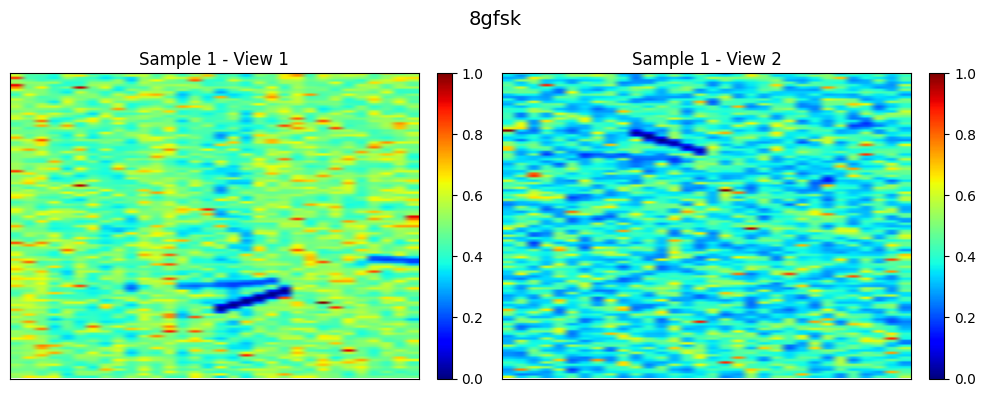

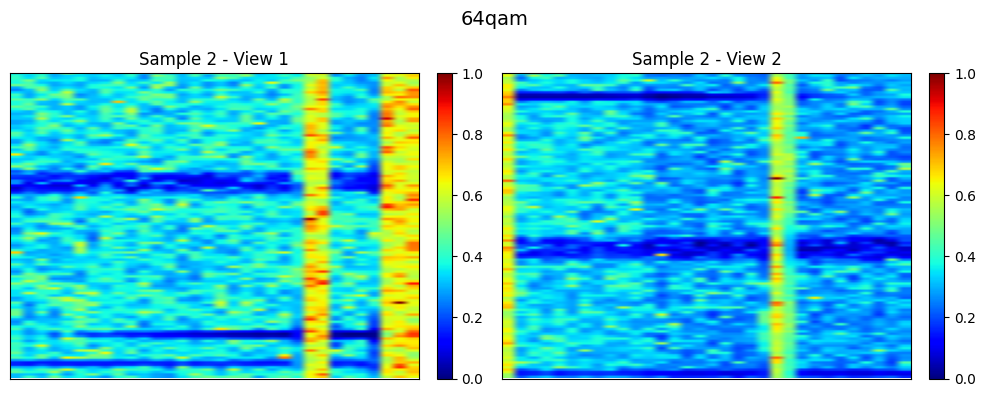

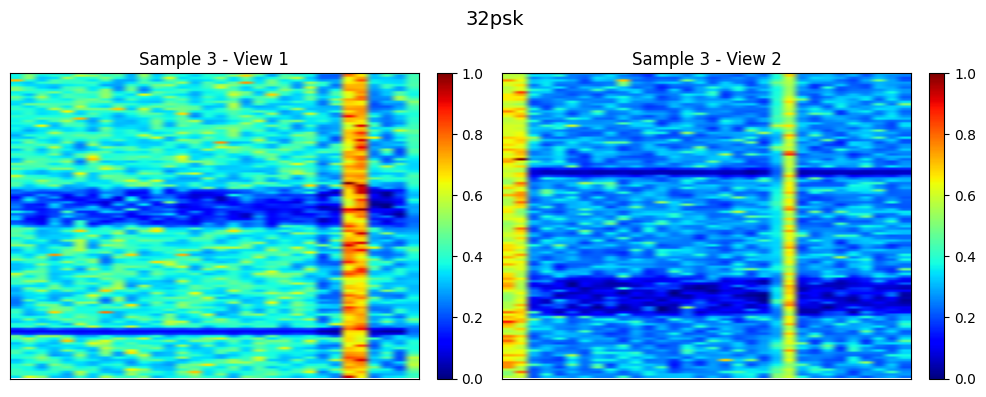

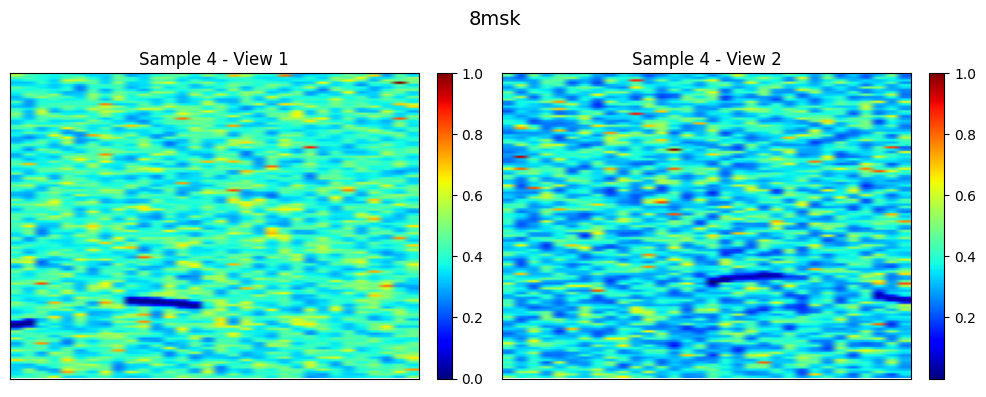

In [ ]:
#datamodule.num_workers = 0
loader = datamodule.train_dataloader()
batch = next(iter(loader))
visualize_batch(batch, mode="spectrogram", )

# DenseCL

In [ ]:
densecl_wideband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_WIDEBAND,
    download=False,
    spectrogram=True,
    ssl_model=SSLModelType.DENSECL,
    batch_size=2,
    nfft=512,
    num_samples=10,
)

densecl_narrowband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_NARROWBAND,
    download=True,
    spectrogram=True,
    ssl_model=SSLModelType.DENSECL,
    batch_size=2,
    nfft=256,
)

In [ ]:
datamodule = build_dataloader(densecl_wideband_config)
datamodule.prepare_data()
datamodule.setup("fit")

In [ ]:
visualize(10, datamodule.train_dataloader())

In [ ]:
datamodule = build_dataloader(densecl_narrowband_config)
datamodule.prepare_data()
datamodule.setup("fit")

In [ ]:
visualize(10, datamodule.train_dataloader())

## DINO

In [7]:
dino_wideband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_WIDEBAND,
    spectrogram=True,
    ssl_model=SSLModelType.DINO,
    num_workers=0,
    batch_size=1,
    nfft=512,
)

dino_narrowband_config = TrainingConfig(
    root=ROOT ,
    dataset=DatasetType.IQDM_NARROWBAND,
    spectrogram=True,
    ssl_model=SSLModelType.DINO,
    num_workers=0,
    batch_size=4,
    nfft=128,
    num_samples=300,
)

Narrowband

In [4]:
print("🧠 SSL model:", type(dino_narrowband_config.ssl_model), dino_narrowband_config.ssl_model)

datamodule = build_dataloader(dino_narrowband_config)
print(f"🧪 Using DataModule: {type(datamodule)}")
print(f"🧪 Dataset type: {dino_narrowband_config.dataset}")
print(f"🧪 Dataset root path: {dino_narrowband_config.root}")

datamodule.prepare_data()

datamodule.setup("fit")

NameError: name 'dino_narrowband_config' is not defined

📊 Sample Metadata for Inspection:
📊 Matched Sample Metadata:
🧩 Sample 1: Class Index 8 (ShortPulseStudy_Type2_10usec)
  Bandwidth      : 3552913
  Duration       : 5e-05
  Center Freq    : 1981423345.5
----------------------------------------
🧩 Sample 2: Class Index 4 (SIGINTDAY2021_PulseRadar03)
  Bandwidth      : 3649902
  Duration       : 5e-05
  Center Freq    : 1981446337.0
----------------------------------------
🧩 Sample 3: Class Index 15 (SIGINTDAY2021_PulseRadar06 - Subpulse 1)
  Bandwidth      : 3649902
  Duration       : 5e-05
  Center Freq    : 1981446337.0
----------------------------------------
🧩 Sample 4: Class Index 9 (ShortPulseStudy_Type6_10usec)
  Bandwidth      : 3548516
  Duration       : 5e-05
  Center Freq    : 1995691089.0
----------------------------------------


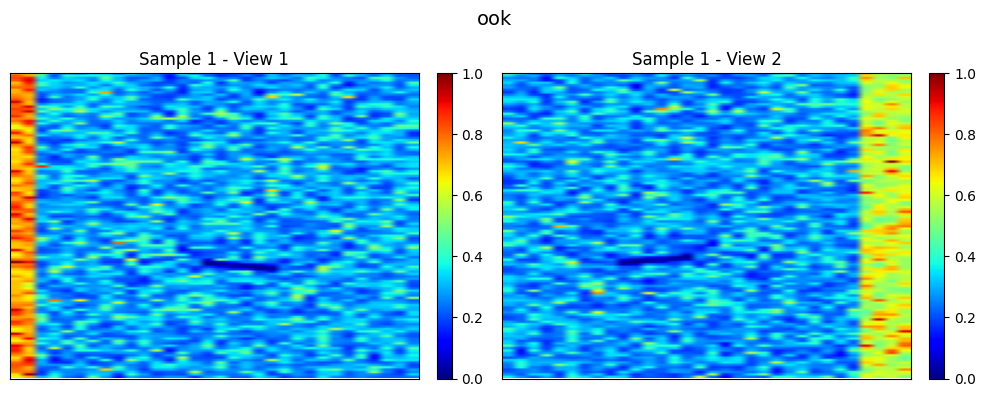

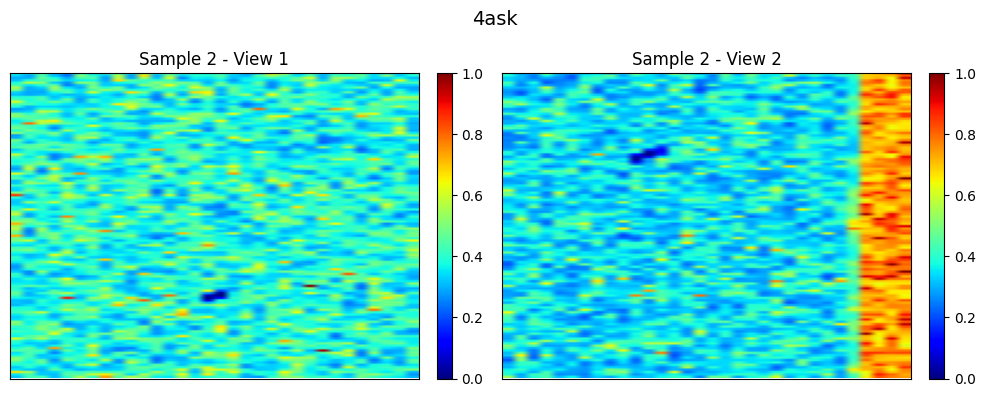

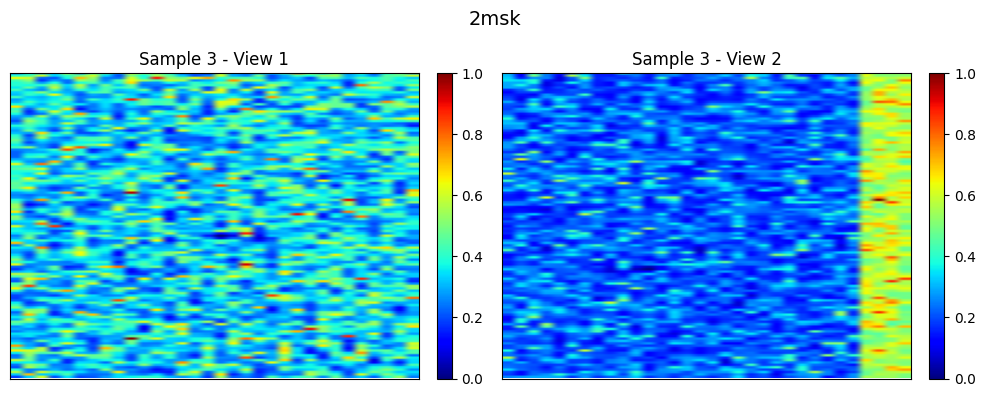

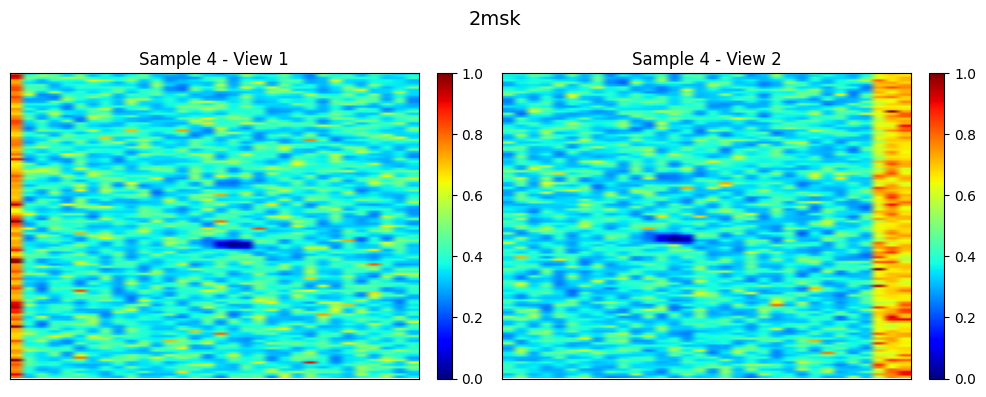

In [9]:
loader = datamodule.train_dataloader()
batch = next(iter(loader))
print("📊 Sample Metadata for Inspection:")
import json

# 🔁 Load feature vectors once
with open("/home/airbus/selfRF/datasets/NARROWBAND_ZARR/feature_vectors.json", "r") as f:
    feature_vectors = json.load(f)

raw_dataset = datamodule.train_dataset

print("📊 Matched Sample Metadata:")
for i in range(4):  # visualize samples 1–4
    signal, meta_tuple = raw_dataset[i]
    class_index = meta_tuple[0][0]
    class_name = meta_tuple[1][0]

    # ✅ Match by sample index, not class_index
    fv = feature_vectors[i]

    print(f"🧩 Sample {i+1}: Class Index {class_index} ({class_name})")
    print("  Bandwidth      :", fv.get("original_bandwidth"))
    print("  Duration       :", fv.get("duration"))
    print("  Center Freq    :", fv.get("original_center_freq"))
    print("-" * 40)


visualize_batch(batch, mode="spectrogram")

## MOCO_V3

In [5]:
mocov3_narrowband_config = TrainingConfig(
    root=ROOT ,
    dataset=DatasetType.IQDM_NARROWBAND,
    spectrogram=True,
    ssl_model=SSLModelType.MOCOV3,
    num_workers=0,
    batch_size=4,
    nfft=128,
    num_samples=300,
)

Narrowband

In [6]:
print("🧠 SSL model:", type(mocov3_narrowband_config.ssl_model), mocov3_narrowband_config.ssl_model)

datamodule = build_dataloader(mocov3_narrowband_config)
print(f"🧪 Using DataModule: {type(datamodule)}")
print(f"🧪 Dataset type: {mocov3_narrowband_config.dataset}")
print(f"🧪 Dataset root path: {mocov3_narrowband_config.root}")

datamodule.prepare_data()

datamodule.setup("fit")

🧠 SSL model: <enum 'SSLModelType'> SSLModelType.MOCOV3
[DEBUG] Building collate function. Validation: False | Stage: ssl
[DEBUG] Using MultiViewCollate
[DEBUG] Building collate function. Validation: True | Stage: ssl
[DEBUG] Using MultiViewCollate
🧪 Using DataModule: <class 'selfrf.data.iqdm.iqdm_modules.IQDMNarrowbandDataModule'>
🧪 Dataset type: DatasetType.IQDM_NARROWBAND
🧪 Dataset root path: ../datasets


📊 Sample Metadata for Inspection:
📊 Matched Sample Metadata:
🧩 Sample 1: Class Index 39 (ShortPulseStudy_Type4_10usec)
  Bandwidth      : None
  Duration       : 0.05
  Center Freq    : None
----------------------------------------
🧩 Sample 2: Class Index 23 (SIGINTDAY2021_PulseRadar08 - Subpulse 3)
  Bandwidth      : None
  Duration       : 0.05
  Center Freq    : None
----------------------------------------
🧩 Sample 3: Class Index 31 (SIGENCESim FM20kHz)
  Bandwidth      : None
  Duration       : 0.05
  Center Freq    : None
----------------------------------------
🧩 Sample 4: Class Index 18 (SIGINTDAY2021_PulseRadar05 - Subpulse 2)
  Bandwidth      : None
  Duration       : 0.05
  Center Freq    : None
----------------------------------------


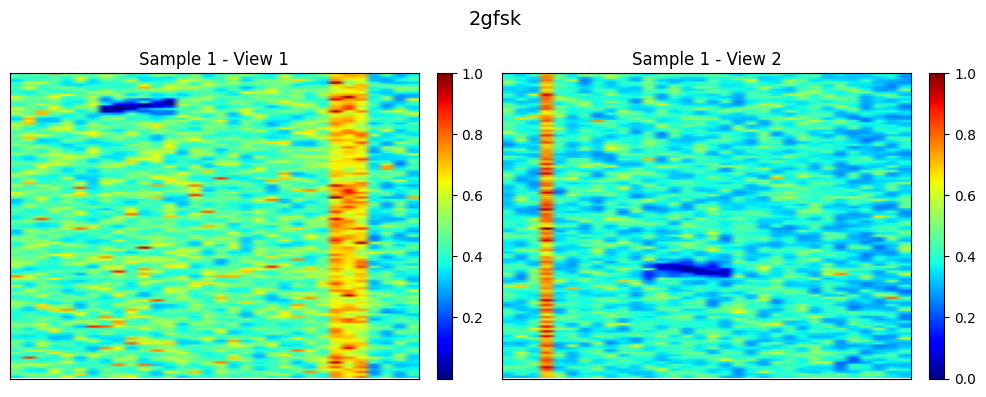

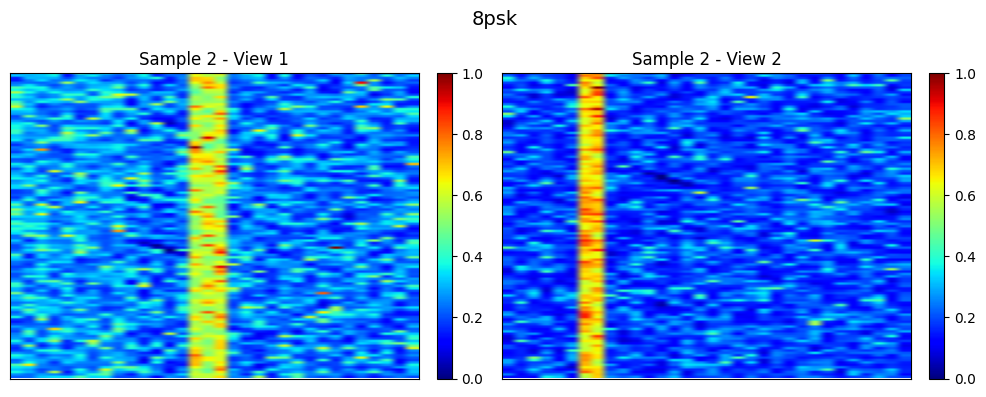

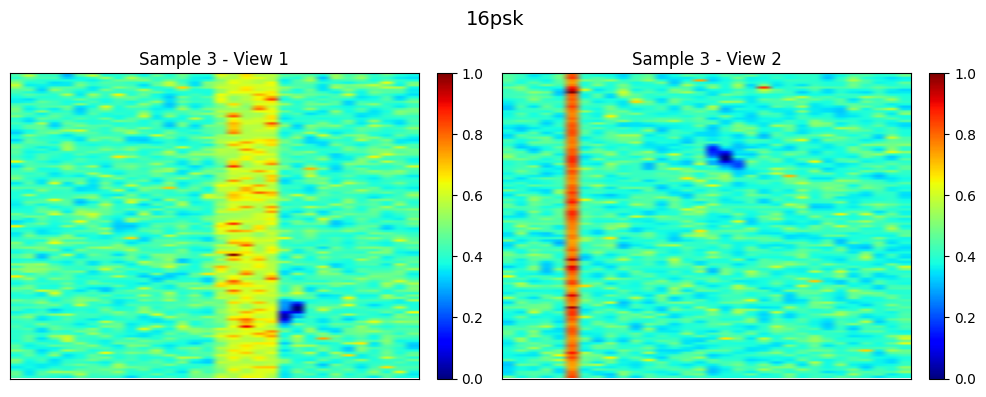

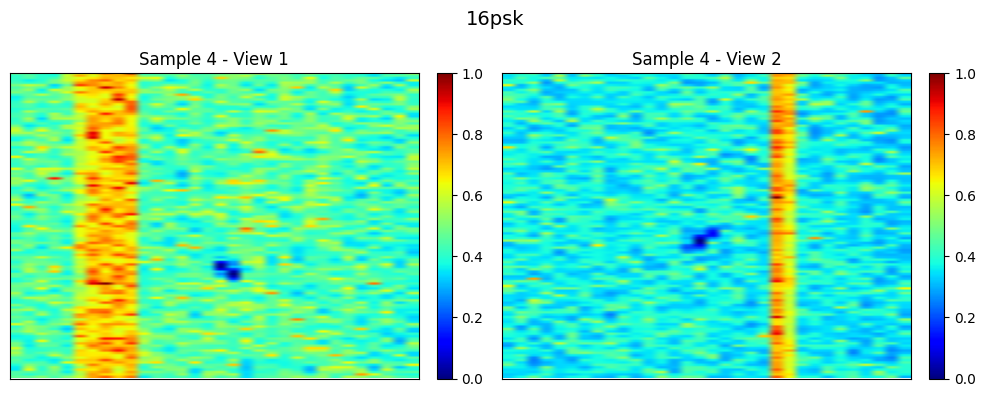

In [7]:
loader = datamodule.train_dataloader()
batch = next(iter(loader))
print("📊 Sample Metadata for Inspection:")
import json

# 🔁 Load feature vectors once
with open("/home/airbus/selfRF/datasets/NARROWBAND_ZARR/feature_vectors.json", "r") as f:
    feature_vectors = json.load(f)

raw_dataset = datamodule.train_dataset

print("📊 Matched Sample Metadata:")
for i in range(4):  # visualize samples 1–4
    signal, meta_tuple = raw_dataset[i]
    class_index = meta_tuple[0][0]
    class_name = meta_tuple[1][0]

    # ✅ Match by sample index, not class_index
    fv = feature_vectors[i]

    print(f"🧩 Sample {i+1}: Class Index {class_index} ({class_name})")
    print("  Bandwidth      :", fv.get("original_bandwidth"))
    print("  Duration       :", fv.get("duration"))
    print("  Center Freq    :", fv.get("original_center_freq"))
    print("-" * 40)


visualize_batch(batch, mode="spectrogram")

[DEBUG] Building collate function. Validation: False | Stage: ssl
[DEBUG] Using MultiViewCollate
[DEBUG] Building collate function. Validation: True | Stage: ssl
[DEBUG] Using MultiViewCollate


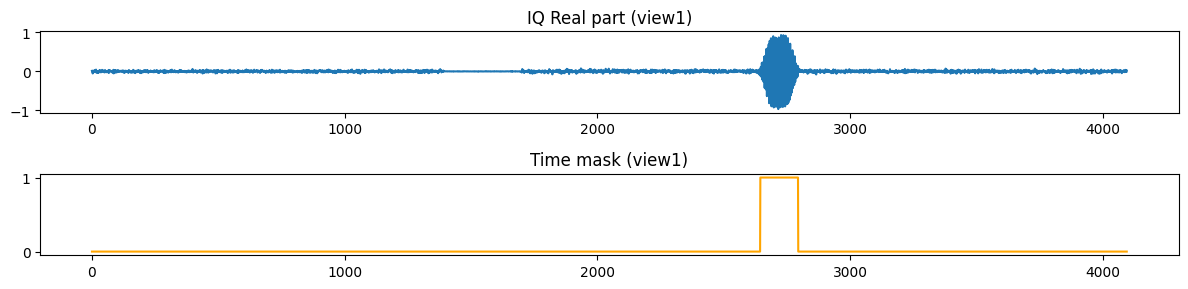

In [8]:
from selfrf.pretraining.config import TrainingConfig
# ✅ Build config as you normally do
mocov3_narrowband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.IQDM_NARROWBAND,
    spectrogram=False,  # Important: we stay in IQ domain
    ssl_model=SSLModelType.MOCOV3,
    num_workers=0,
    batch_size=4,
    nfft=128,
    num_samples=300,
)

# ✅ Build datamodule and dataloader
datamodule = build_dataloader(mocov3_narrowband_config)
datamodule.prepare_data()
datamodule.setup("fit")
loader = datamodule.train_dataloader()

# ✅ Grab first batch
batch = next(iter(loader))

# ✅ Unpack batch according to your collate function (for MultiViewCollate with masks)
((view1_iq, view1_mask), (view2_iq, view2_mask)), labels = batch

# ✅ Simple check — visualize one mask + corresponding IQ
import matplotlib.pyplot as plt

sample_idx = 0  # pick first sample
plt.figure(figsize=(12, 3))
plt.subplot(2, 1, 1)
plt.title("IQ Real part (view1)")
plt.plot(view1_iq[sample_idx, 0].numpy())  # assuming shape [B, 2, L]

plt.subplot(2, 1, 2)
plt.title("Time mask (view1)")
plt.plot(view1_mask[sample_idx].numpy(), color='orange')

plt.tight_layout()
plt.show()


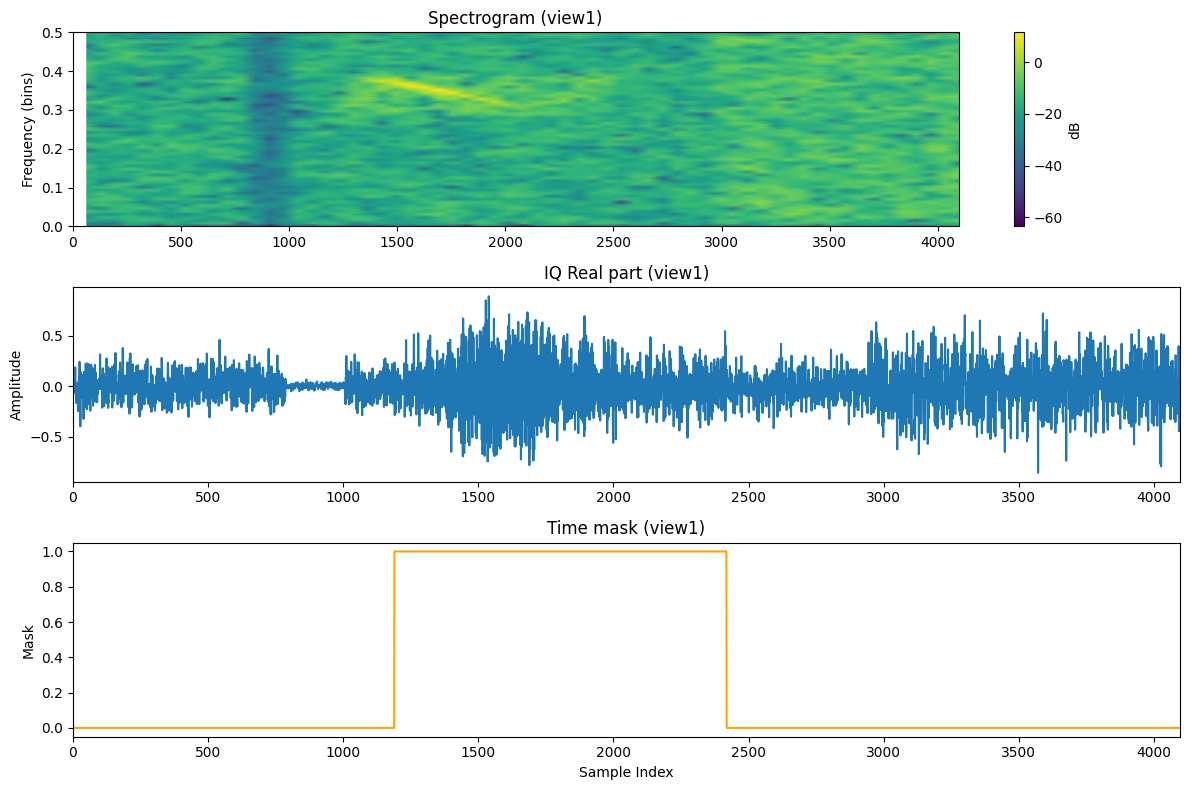

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# ✅ Select sample index to visualize
sample_idx = 3

# ✅ Extract IQ and mask
iq = view1_iq[sample_idx].numpy()  # shape [2, L]  → e.g. [2, 4096]
mask = view1_mask[sample_idx].numpy()  # shape [L] → e.g. [4096]

# ✅ Setup spectrogram params to match IQ length
nperseg = 128
noverlap = 64
fs = 1  # Sampling frequency is arbitrary unit

# ✅ Compute spectrogram
f, t_spec, Sxx = spectrogram(iq[0], fs=fs, nperseg=nperseg, noverlap=noverlap)

# ✅ Convert spectrogram time axis into full sample index (same domain as mask & IQ)
t_spec_samples = t_spec * (len(iq[0]) / t_spec[-1])  # Rescale time axis to match sample indices

plt.figure(figsize=(12, 8))

# ✅ Plot spectrogram
plt.subplot(3, 1, 1)
plt.title("Spectrogram (view1)")
plt.pcolormesh(t_spec_samples, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud')
plt.ylabel("Frequency (bins)")
plt.colorbar(label='dB')
plt.xlim([0, len(iq[0])])

# ✅ Plot IQ real part
plt.subplot(3, 1, 2)
plt.title("IQ Real part (view1)")
plt.plot(np.arange(len(iq[0])), iq[0])
plt.ylabel("Amplitude")
plt.xlim([0, len(iq[0])])

# ✅ Plot mask
plt.subplot(3, 1, 3)
plt.title("Time mask (view1)")
plt.plot(np.arange(len(mask)), mask, color='orange')
plt.xlabel("Sample Index")
plt.ylabel("Mask")
plt.xlim([0, len(iq[0])])

plt.tight_layout()
plt.show()



In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Create iterator outside the cell (only once)
if "sample_iterator" not in globals():
    loader = datamodule.train_dataloader()
    batch = next(iter(loader))
    ((view1_iq, view1_mask), (view2_iq, view2_mask)), labels = batch
    sample_iterator = iter(range(view1_iq.shape[0]))

# Get next sample
try:
    sample_idx = next(sample_iterator)
except StopIteration:
    print("✅ All samples visualized in current batch.")
    del sample_iterator
    raise

# Visualization code
iq = view1_iq[sample_idx].numpy()
mask = view1_mask[sample_idx].numpy()

f, t_spec, Sxx = spectrogram(iq[0], nperseg=128, noverlap=64)
t_spec_samples = t_spec * (len(iq[0]) / t_spec[-1])

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.title(f"Spectrogram (view1) - Sample {sample_idx}")
plt.pcolormesh(t_spec_samples, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud')
plt.ylabel("Frequency (bins)")
plt.colorbar(label='dB')
plt.xlim([0, len(iq[0])])

plt.subplot(3, 1, 2)
plt.title("IQ Real part (view1)")
plt.plot(np.arange(len(iq[0])), iq[0])
plt.ylabel("Amplitude")
plt.xlim([0, len(iq[0])])

plt.subplot(3, 1, 3)
plt.title("Time mask (view1)")
plt.plot(np.arange(len(mask)), mask, color='orange')
plt.xlabel("Sample Index")
plt.ylabel("Mask")
plt.xlim([0, len(iq[0])])

plt.tight_layout()
plt.show()


NameError: name 'datamodule' is not defined

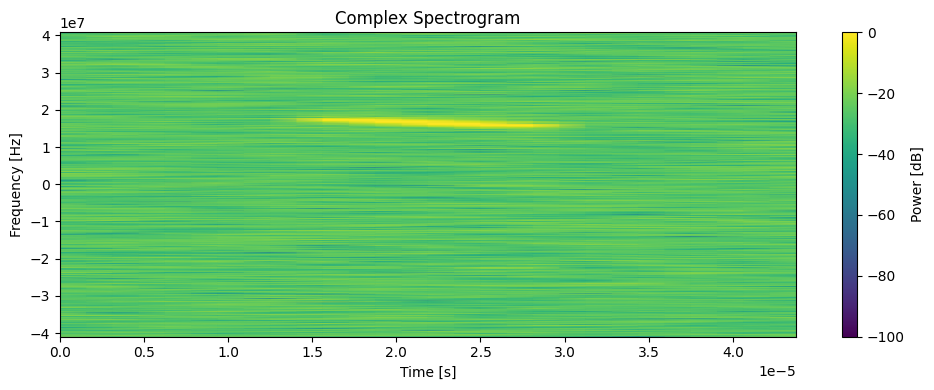

In [69]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_complex_spectrogram(samples, sample_rate=1e6, nfft=512):
    """
    Proper complex-valued spectrogram (baseband).
    """
    from numpy.lib import stride_tricks

    hop_size = nfft // 2
    n_frames = (len(samples) - nfft) // hop_size + 1

    # Create overlapping frames
    frames = stride_tricks.sliding_window_view(samples, nfft)[::hop_size]

    # Compute FFT on each frame
    spec = np.fft.fftshift(np.fft.fft(frames, axis=-1), axes=-1)
    spec_power = 10 * np.log10(np.abs(spec) ** 2 + 1e-12)

    freqs = np.fft.fftshift(np.fft.fftfreq(nfft, d=1 / sample_rate))
    times = np.arange(n_frames) * hop_size / sample_rate

    plt.figure(figsize=(10, 4))
    plt.pcolormesh(times, freqs, spec_power.T, shading='gouraud', cmap='viridis', vmin=-100, vmax=0)
    plt.ylabel("Frequency [Hz]")
    plt.xlabel("Time [s]")
    plt.title("Complex Spectrogram")
    plt.colorbar(label="Power [dB]")
    plt.tight_layout()
    plt.show()


import zarr
import numpy as np

# Load Zarr dataset
zarr_path = "/home/airbus/selfRF/datasets/NARROWBAND_ZARR-org/data.zarr"
zarr_store = zarr.open_array(zarr_path, mode="r")
metadata = zarr_store.attrs

# Pick sample
sample_idx = 77
sample = zarr_store[sample_idx]
sample_metadata = metadata[str(sample_idx)][0]

# Visualize
visualize_complex_spectrogram(sample, sample_rate=sample_metadata["sample_rate"])

Loaded Zarr dataset with shape: (128572, 4096)

Displaying signal 62900


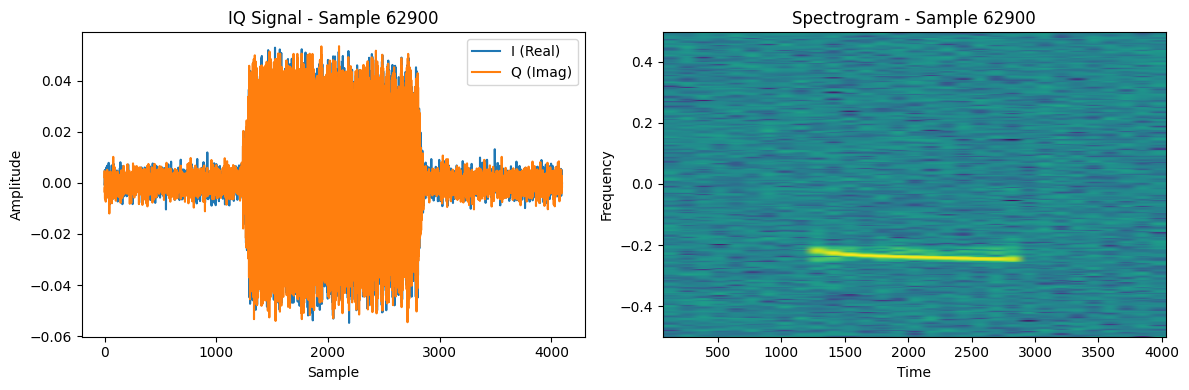


Displaying signal 121102


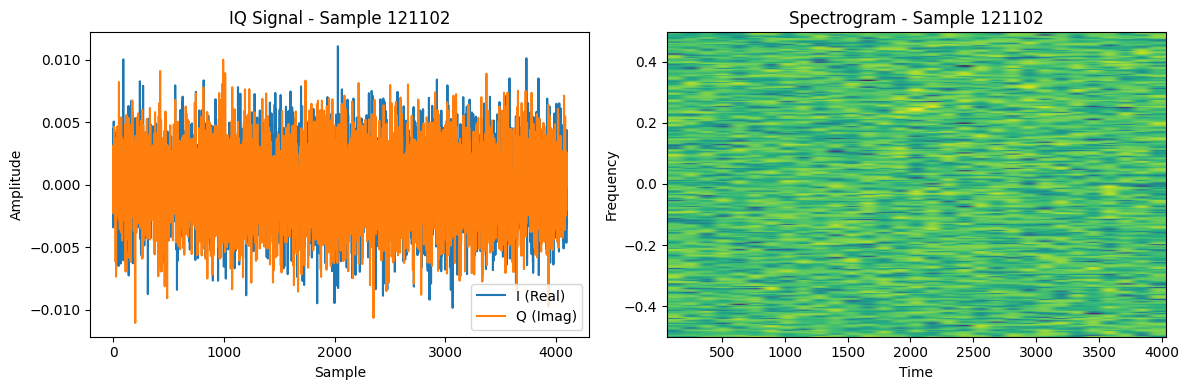


Displaying signal 40435


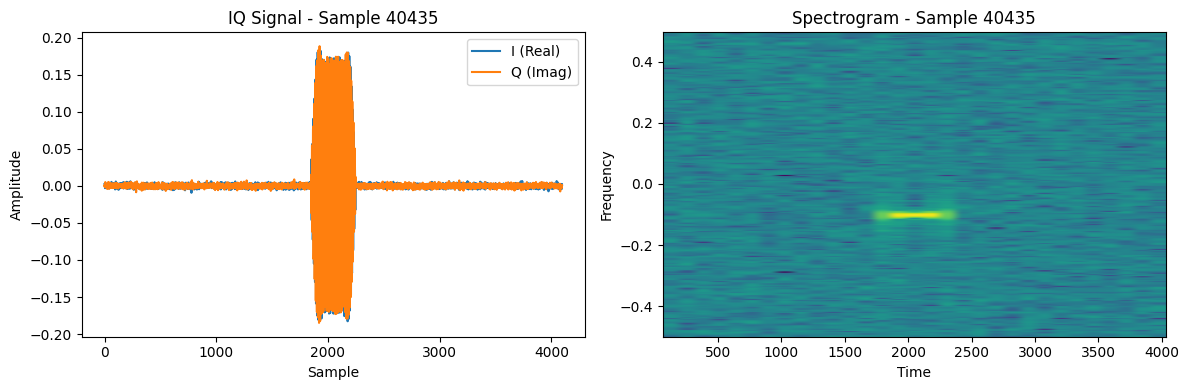

In [2]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
import random

# Path to your Zarr file
ZARR_PATH = "/home/airbus/selfRF/datasets/NARROWBAND_ZARR/data.zarr"

# Load Zarr dataset
zarr_data = zarr.open_array(ZARR_PATH, mode='r')
print(f"Loaded Zarr dataset with shape: {zarr_data.shape}")

# Visualize N random signals
N = 3
frame_size = zarr_data.shape[1]

for _ in range(N):
    idx = random.randint(0, zarr_data.shape[0] - 1)
    signal = zarr_data[idx]

    print(f"\nDisplaying signal {idx}")

    # Plot IQ components
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(np.real(signal), label="I (Real)")
    plt.plot(np.imag(signal), label="Q (Imag)")
    plt.title(f"IQ Signal - Sample {idx}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.legend()

    # Plot Spectrogram
    plt.subplot(1, 2, 2)
    plt.specgram(signal, NFFT=256, Fs=1.0, noverlap=128, scale='dB')
    plt.title(f"Spectrogram - Sample {idx}")
    plt.xlabel("Time")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


Selected file: VariationStudy_-_Emitter_SIGINTDAY2021_PulseRadar08_Subpulse_3.sigmf-meta
✅ Normalized Annotation:
  start=1685 length=726
  flo=-1971940  fhi=2084622
✅ Visualizing signal 0, Raw Power: -55.60 dB


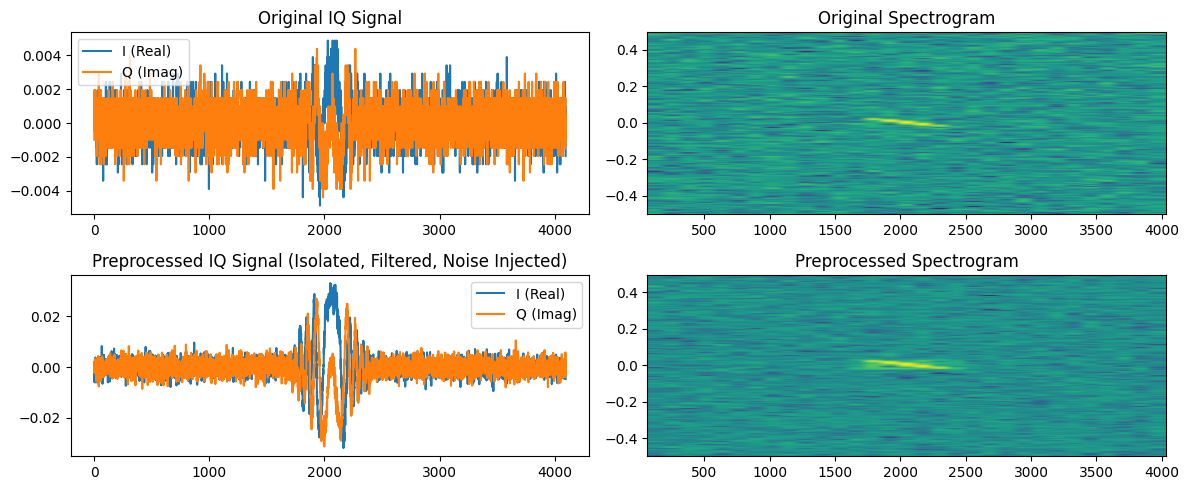

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import random
from sigmf.sigmffile import SigMFFile
from selfrf.data.iqdm.narrowband import (
    filter_frequency,
    isolate_signal_with_target_power_and_snr,
    normalize_annotation_to_frame,
    get_capture_for_annotation,
    compute_signal_power
)

# Config
INPUT_FOLDER = "/home/airbus/selfRF/datasets/VariationStudy+test"
FRAME_SIZE = 4096

# Get .sigmf-meta files
meta_files = [os.path.join(INPUT_FOLDER, f) for f in os.listdir(INPUT_FOLDER) if f.endswith(".sigmf-meta")]
if not meta_files:
    raise FileNotFoundError("No .sigmf-meta files found.")

# Pick random file
meta_path = random.choice(meta_files)
data_path = meta_path.replace(".sigmf-meta", ".sigmf-data")

print(f"Selected file: {os.path.basename(meta_path)}")

# Load metadata manually (avoiding JSONDecodeError)
with open(meta_path, "r", encoding="utf-8") as f:
    metadata_json = json.load(f)

sigmf_file = SigMFFile(skip_checksum=True)
sigmf_file.set_metadata(metadata_json)
sigmf_file.set_data_file(data_path, skip_checksum=True)

annotations = sigmf_file.get_annotations()
sample_rate = sigmf_file.get_global_field(SigMFFile.SAMPLE_RATE_KEY)
file_length = len(sigmf_file)

# Find first valid annotation
for index, annotation in enumerate(annotations):
    
    # Apply same filtering as in your pipeline
    if file_length < annotation[SigMFFile.START_INDEX_KEY] + FRAME_SIZE:
        continue
    if annotation[SigMFFile.FLO_KEY] >= annotation[SigMFFile.FHI_KEY]:
        continue
    if "(partly)" in annotation[SigMFFile.LABEL_KEY]:
        continue

    capture = get_capture_for_annotation(sigmf_file, annotation)

    # Frame placement logic identical to your preprocessing
    if annotation[SigMFFile.LENGTH_INDEX_KEY] > FRAME_SIZE:
        annotation[SigMFFile.LENGTH_INDEX_KEY] = FRAME_SIZE
        global_sample_start = annotation[SigMFFile.START_INDEX_KEY]
    else:
        global_sample_start = annotation[SigMFFile.START_INDEX_KEY] - (
            FRAME_SIZE - annotation[SigMFFile.LENGTH_INDEX_KEY]) // 2

    global_sample_start = max(0, global_sample_start)
    global_sample_count = FRAME_SIZE

    # Normalize annotation to frame (baseband shift)
    normalized_annotation = normalize_annotation_to_frame(
        annotation, global_sample_start, global_sample_count, capture.get("core:frequency", 0.0)
    )
    if normalized_annotation is None:
        continue

    # Read raw IQ samples
    samples = sigmf_file.read_samples(global_sample_start, global_sample_count)

    # Compute power BEFORE isolation
    signal_power_linear, signal_power_db = compute_signal_power(samples)

    print(f"✅ Visualizing signal {index}, Raw Power: {signal_power_db:.2f} dB")

    # Isolation identical to your pipeline
    processed_samples, processed_power_db, boost = isolate_signal_with_target_power_and_snr(
        samples=samples,
        sample_rate=sample_rate,
        sample_start=normalized_annotation[SigMFFile.START_INDEX_KEY],
        sample_count=normalized_annotation[SigMFFile.LENGTH_INDEX_KEY],
        f_low=normalized_annotation[SigMFFile.FLO_KEY],
        f_high=normalized_annotation[SigMFFile.FHI_KEY],
        target_power=1.0,
        snr_db=np.random.uniform(45, 55)
    )

    # Plot original signal
    plt.figure(figsize=(12, 5))
    plt.subplot(2, 2, 1)
    plt.plot(np.real(samples), label="I (Real)")
    plt.plot(np.imag(samples), label="Q (Imag)")
    plt.title("Original IQ Signal")
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.specgram(samples, NFFT=256, Fs=1.0, noverlap=128, scale='dB')
    plt.title("Original Spectrogram")

    # Plot preprocessed signal
    plt.subplot(2, 2, 3)
    plt.plot(np.real(processed_samples), label="I (Real)")
    plt.plot(np.imag(processed_samples), label="Q (Imag)")
    plt.title("Preprocessed IQ Signal (Isolated, Filtered, Noise Injected)")
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.specgram(processed_samples, NFFT=256, Fs=1.0, noverlap=128, scale='dB')
    plt.title("Preprocessed Spectrogram")

    plt.tight_layout()
    plt.show()

    break  # Visualize only first valid signal

